In [42]:
# Import required libraries
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import importlib


In [47]:

# Add current directory to path to import our modules
if '.' not in sys.path:
    sys.path.append('.')

# Import our modules
from models import ObjectDetectionModel, ObjectDetectionDataModule
from utils import plot_image
from onnx_conversion import export_to_onnx, verify_onnx_model


In [62]:

# reload modules to get the latest changes
import models
import utils
import onnx_conversion

importlib.reload(models)
importlib.reload(utils)
importlib.reload(onnx_conversion)

from models import ObjectDetectionModel, ObjectDetectionDataModule
from utils import plot_image, plot_side_by_side, compare_pytorch_onnx_side_by_side
from onnx_conversion import export_to_onnx, verify_onnx_model


# Step 1: Initialize the model and data module

In [52]:
import os
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define constants
width = 520
height = 240
image_dir_train = "./Dataset/dataset_syn/images/train"
image_dir_val = "./Dataset/dataset_syn/images/val"

# Set up grid lines
grid_lines = [[0, 0.2, 0.4, 0.6, 0.8, 1], [0, 1]]
grid_lines[0] = [line * width for line in grid_lines[0]]
grid_lines[1] = [line * height for line in grid_lines[1]]
danger_levels = 3

# Training parameters
max_epochs = 10  # Adjust as needed
batch_size = 8
checkpoint_path = "./model_checkpoints"
os.makedirs(checkpoint_path, exist_ok=True)

# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath=checkpoint_path,
    filename='object_detection-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    monitor='val_loss',
    mode='min'
)

# Training flag - set to True if you want to train the model, False to load a saved model
train_model = True

# Initialize our ONNX-compatible model
model = ObjectDetectionModel(grid_lines, danger_levels, input_shape=(3, height, width))

# Initialize the data module
data_module = ObjectDetectionDataModule(
    image_dir_train, 
    image_dir_val, 
    width, 
    height, 
    grid_lines, 
    danger_levels, 
    batch_size=batch_size, 
    device=device
)

Using device: cuda


# Step 2: Train the model or load from checkpoint

In [53]:


if train_model:
    # Setup PyTorch Lightning trainer
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        callbacks=[checkpoint_callback],
        check_val_every_n_epoch=1,
        log_every_n_steps=10
    )
    
    # Train the model
    print("Starting model training...")
    trainer.fit(model, data_module)
    
    # Get the best checkpoint path
    best_model_path = checkpoint_callback.best_model_path
    if best_model_path:
        print(f"Best model saved at: {best_model_path}")
        # Load the best model
        model = ObjectDetectionModel.load_from_checkpoint(best_model_path, grid_lines=grid_lines, danger_levels=danger_levels)
    else:
        print("No checkpoints saved. Using the final model state.")
else:
    # Load model from a predefined checkpoint
    checkpoint_file = "checkpoint_filename.ckpt"  # Replace with your checkpoint filename
    checkpoint_full_path = os.path.join(checkpoint_path, checkpoint_file)
    
    if os.path.exists(checkpoint_full_path):
        print(f"Loading model from checkpoint: {checkpoint_full_path}")
        model = ObjectDetectionModel.load_from_checkpoint(
            checkpoint_full_path, 
            grid_lines=grid_lines, 
            danger_levels=danger_levels
        )
    else:
        print(f"Checkpoint file not found: {checkpoint_full_path}")
        print("Proceeding with untrained model.")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\danie\Documents\GitHub\paparazzi\SmallConvNetwork\model_checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | conv_features | Sequential | 173 K  | train
1 | fc_layers     | Sequential | 14.7 M | train
2 | loss_fn       | BCELoss    | 0      | train
-----------------------------------------------------
14.9 M    Trainable params
0         Non-trainable params
14.9 M    Total params
59.436    Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Starting model training...
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Best model saved at: C:\Users\danie\Documents\GitHub\paparazzi\SmallConvNetwork\model_checkpoints\object_detection-epoch=09-val_loss=0.14.ckpt


# Step 3: Evaluate the model on validation set

In [54]:


print("Evaluating model on validation set...")
model.eval()
trainer = pl.Trainer(accelerator='gpu' if torch.cuda.is_available() else 'cpu')
val_results = trainer.validate(model, datamodule=data_module)
print(f"Validation results: {val_results}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating model on validation set...
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss            0.1376274824142456
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Validation results: [{'val_loss': 0.1376274824142456}]


# Step 4: Visualize some predictions on validation data

[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels


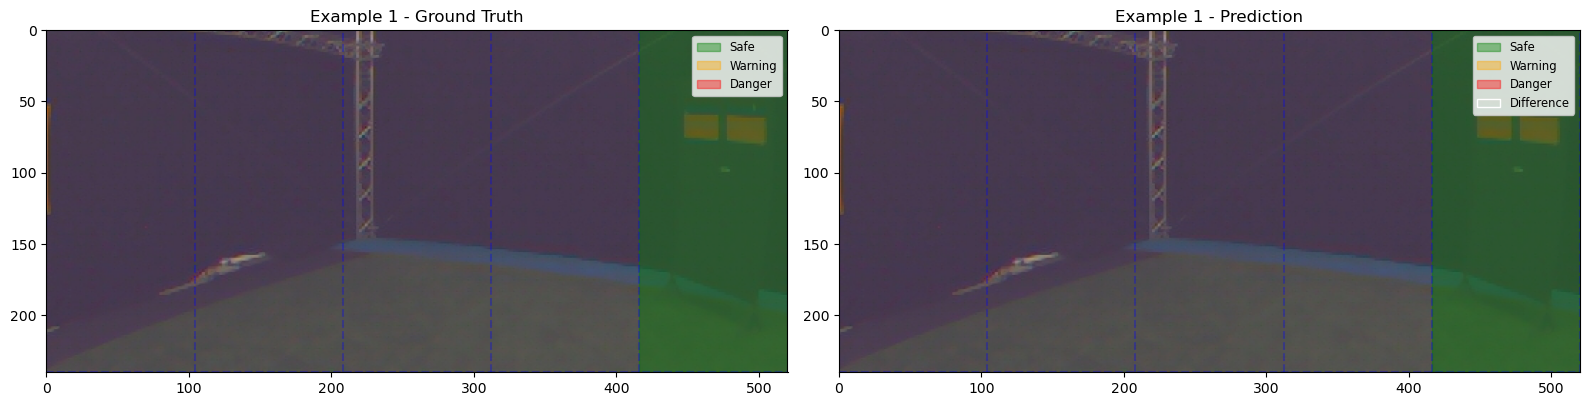

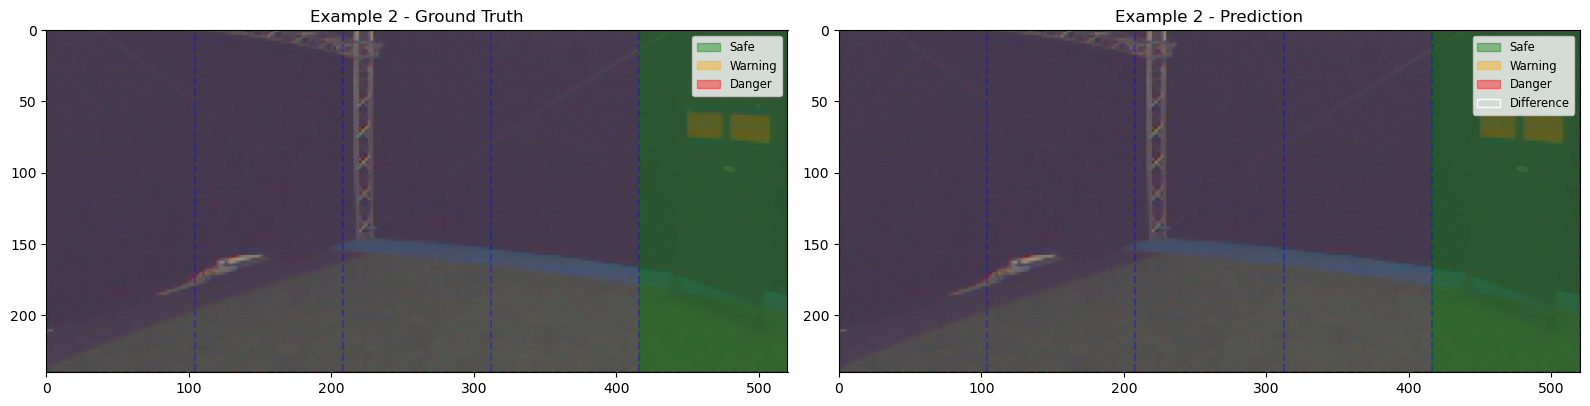

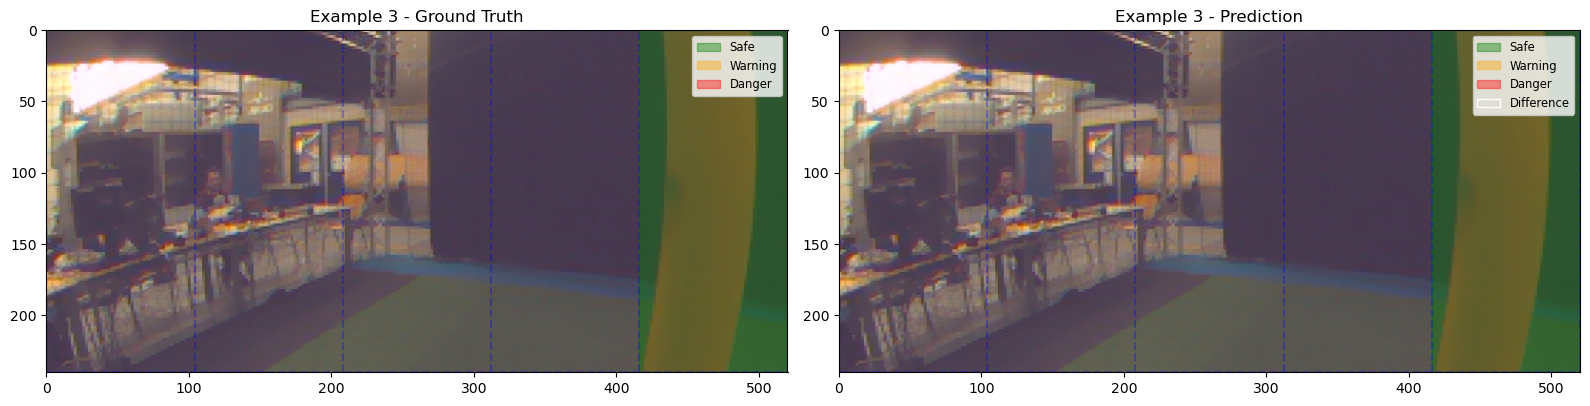

In [55]:

data_module.setup()
val_dataloader = data_module.val_dataloader()

# Get a batch of validation data
val_batch = next(iter(val_dataloader))
images, targets = val_batch

# Move the model to the same device as the input data
device = images.device
model = model.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(images)

# Display a few examples side by side
batch_size = images.shape[0]
num_examples = min(3, batch_size)

for i in range(num_examples):
    # Plot ground truth and prediction side by side
    plot_side_by_side(
        image=images[i],
        ground_truth=targets[i],
        prediction=predictions[i],
        grid_lines=grid_lines,
        example_num=i+1
    )
    plt.show()

# Step 5: Convert the PyTorch model to ONNX

In [57]:
# Move model to CPU, then convert to ONNX
model = model.to('cpu')
dummy_input = torch.randn(1, 3, height, width, device='cpu')

export_to_onnx(model, input_shape=(1, 3, height, width), output_path="./object_detection.onnx")

Model exported to ./object_detection.onnx


'./object_detection.onnx'

In [58]:

# Try loading the model to verify it works
import onnxruntime
ort_session = onnxruntime.InferenceSession("object_detection.onnx")

# Test with a sample input
test_input = images[0:1].cpu().numpy()
ort_inputs = {ort_session.get_inputs()[0].name: test_input}
ort_outputs = ort_session.run(None, ort_inputs)

print("Direct ONNX export successful!")

Direct ONNX export successful!


[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels


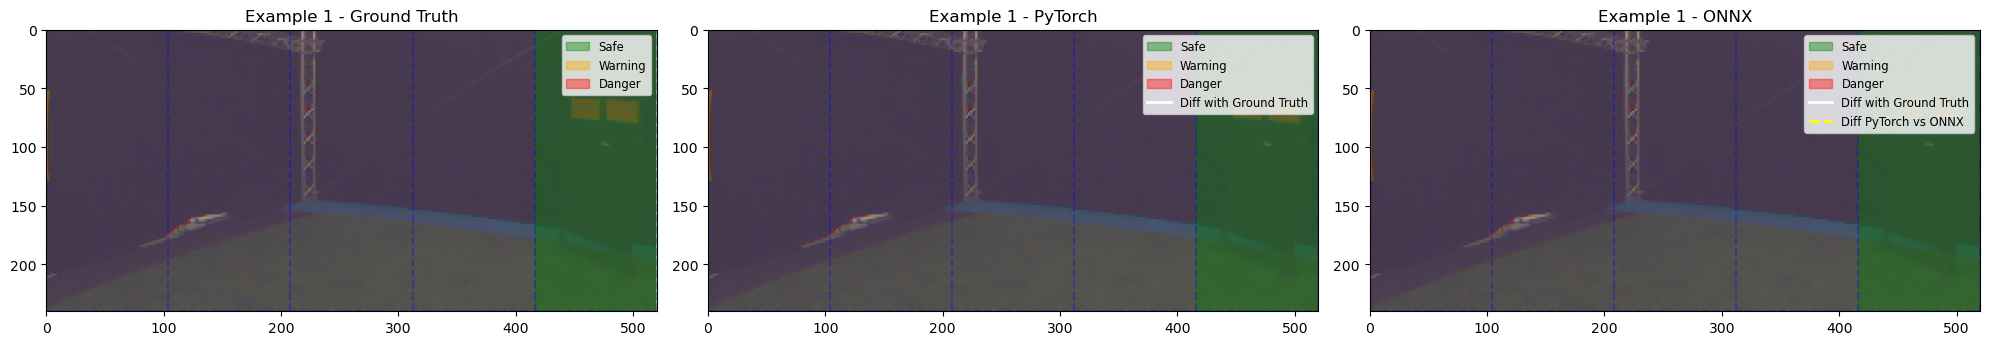

Example 1 - Maximum absolute differences:
  PyTorch vs Ground Truth: 0.000720
  ONNX vs Ground Truth: 0.000720
  PyTorch vs ONNX: 0.000000


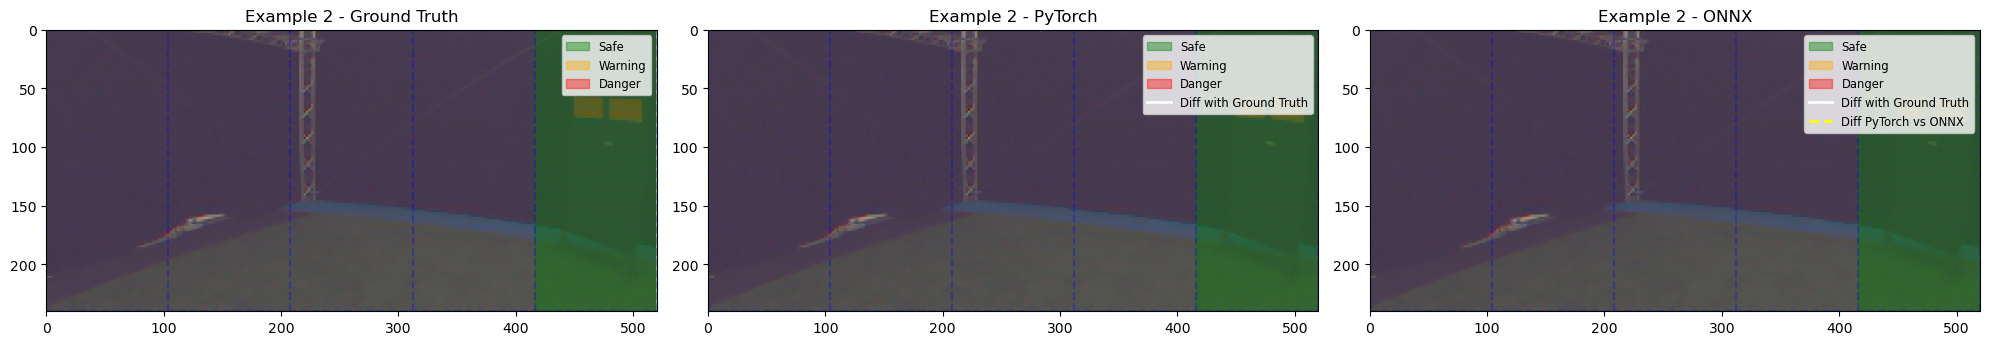

Example 2 - Maximum absolute differences:
  PyTorch vs Ground Truth: 0.000697
  ONNX vs Ground Truth: 0.000697
  PyTorch vs ONNX: 0.000000


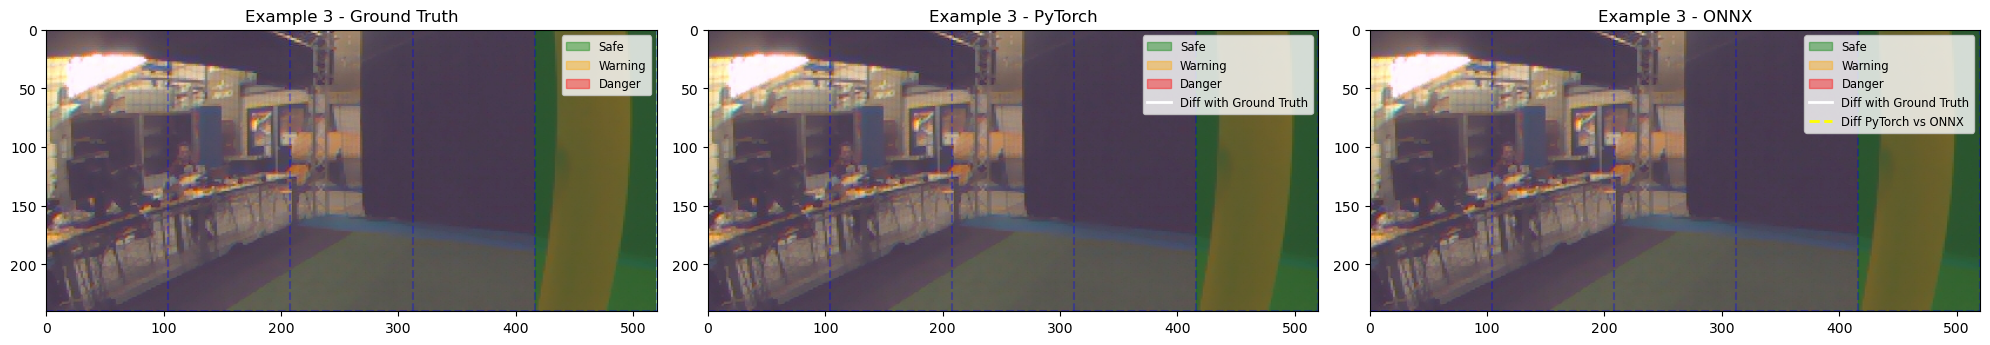

Example 3 - Maximum absolute differences:
  PyTorch vs Ground Truth: 0.012185
  ONNX vs Ground Truth: 0.012185
  PyTorch vs ONNX: 0.000000


In [63]:
def run_pytorch_onnx_comparison(model, onnx_path, data_module, num_examples=3):
    """
    Run comparison between PyTorch and ONNX models
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        num_examples: Number of examples to visualize
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Get a batch of validation data
    val_batch = next(iter(val_dataloader))
    images, targets = val_batch
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    images = images.to('cpu')
    targets = targets.to('cpu')
    
    # Get PyTorch predictions
    model.eval()
    with torch.no_grad():
        pytorch_predictions = model(images)
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # Get ONNX predictions
    onnx_inputs = {input_name: images.numpy()}
    onnx_outputs = ort_session.run(None, onnx_inputs)
    onnx_predictions = torch.from_numpy(onnx_outputs[0])
    
    # Display examples side by side
    batch_size = images.shape[0]
    num_examples = min(num_examples, batch_size)
    
    for i in range(num_examples):
        # Plot the comparison
        fig, axes = compare_pytorch_onnx_side_by_side(
            image=images[i],
            ground_truth=targets[i],
            pytorch_pred=pytorch_predictions[i],
            onnx_pred=onnx_predictions[i],
            grid_lines=grid_lines,
            example_num=i+1
        )
        plt.show()
        
        # Print numerical differences
        pt_gt_diff = torch.max(torch.abs(pytorch_predictions[i] - targets[i])).item()
        onnx_gt_diff = torch.max(torch.abs(onnx_predictions[i] - targets[i])).item()
        pt_onnx_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
        
        print(f"Example {i+1} - Maximum absolute differences:")
        print(f"  PyTorch vs Ground Truth: {pt_gt_diff:.6f}")
        print(f"  ONNX vs Ground Truth: {onnx_gt_diff:.6f}")
        print(f"  PyTorch vs ONNX: {pt_onnx_diff:.6f}")

# Run the comparison
run_pytorch_onnx_comparison(
    model=model, 
    onnx_path="./object_detection.onnx", 
    data_module=data_module,
    num_examples=3
)

In [66]:
def compare_models_on_dataset(model, onnx_path, data_module, difference_threshold=0.01):
    """
    Compare PyTorch and ONNX models on the entire validation dataset and 
    find examples where they differ significantly
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        difference_threshold: Threshold to consider a difference significant
    
    Returns:
        list: List of tuples (image, ground_truth, pytorch_pred, onnx_pred, max_diff)
              for examples where the difference exceeds the threshold
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    model.eval()
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # List to store examples with significant differences
    significant_differences = []
    
    # Statistics
    total_examples = 0
    total_correct_match = 0
    difference_histogram = []
    
    # Process all batches
    print("Processing validation dataset...")
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_dataloader):
            # Move tensors to CPU
            images = images.to('cpu')
            targets = targets.to('cpu')
            
            # Get PyTorch predictions
            pytorch_predictions = model(images)
            
            # Get ONNX predictions
            onnx_inputs = {input_name: images.numpy()}
            onnx_outputs = ort_session.run(None, onnx_inputs)
            onnx_predictions = torch.from_numpy(onnx_outputs[0])
            
            # Compare predictions for each example in the batch
            for i in range(images.shape[0]):
                total_examples += 1
                
                # Calculate max absolute difference
                max_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
                difference_histogram.append(max_diff)
                
                # Check if predictions match exactly (after thresholding)
                threshold = 0.5
                pytorch_classes = (pytorch_predictions[i] > threshold).int()
                onnx_classes = (onnx_predictions[i] > threshold).int()
                
                exact_match = torch.all(pytorch_classes == onnx_classes).item()
                if exact_match:
                    total_correct_match += 1
                
                # If difference exceeds threshold, save this example
                if max_diff > difference_threshold or not exact_match:
                    significant_differences.append((
                        images[i].clone(),
                        targets[i].clone(),
                        pytorch_predictions[i].clone(),
                        onnx_predictions[i].clone(),
                        max_diff,
                        exact_match
                    ))
            
            # Print progress every few batches
            if (batch_idx + 1) % 5 == 0 or batch_idx == len(val_dataloader) - 1:
                print(f"Processed {batch_idx+1}/{len(val_dataloader)} batches, "
                      f"found {len(significant_differences)} examples with significant differences")
    
    # Print summary statistics
    print("\nValidation Dataset Summary:")
    print(f"Total examples processed: {total_examples}")
    print(f"Examples with exact class match: {total_correct_match} ({100 * total_correct_match / total_examples:.2f}%)")
    print(f"Examples with significant differences: {len(significant_differences)}")
    
    # Calculate and print difference statistics
    if difference_histogram:
        avg_diff = sum(difference_histogram) / len(difference_histogram)
        max_diff = max(difference_histogram)
        print(f"Average max difference: {avg_diff:.6f}")
        print(f"Maximum difference: {max_diff:.6f}")
    
    return significant_differences

# Run the comparison
significant_differences = compare_models_on_dataset(
    model=model, 
    onnx_path="./object_detection.onnx", 
    data_module=data_module,
    difference_threshold=0.0001  # Adjust this threshold as needed
)

print(f"\nFound {len(significant_differences)} examples with significant differences")

[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
Processing validation dataset...
Processed 5/33 batches, found 0 examples with significant differences
Processed 10/33 batches, found 0 examples with significant differences
Processed 15/33 batches, found 0 examples with significant differences
Processed 20/33 batches, found 0 examples with significant differences
Processed 25/33 batches, found 0 examples with significant differences
Processed 30/33 batches, found 0 examples with significant differences
Processed 33/33 batches, found 0 examples with significant differences

Validation Dataset Summary:
Total examples processed: 261
Examples with exact class match: 261 (100.00%)
Examples with significant differences: 0
Average max difference: 0.000000
Maximum difference: 0.000001

Found 0 examples with significant differences
